In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from google.colab import files
files.upload()

Using device: cuda


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sujal0","key":"4378e307892705cfd3036dcfa01fb2b5"}'}

In [2]:
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

!pip install kaggle --quiet
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip -d brain_mri_data

print(os.listdir("brain_mri_data"))

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:08<00:00, 19.8MB/s]

['Training', 'Testing']


In [3]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(root="brain_mri_data/Training", transform=train_transform)
test_data  = datasets.ImageFolder(root="brain_mri_data/Testing", transform=test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Training images: {len(train_data)}")
print(f"Testing images: {len(test_data)}")
print(f"Classes: {train_data.classes}")



Training images: 5600
Testing images: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
class BrainMRI_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
model = BrainMRI_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} — Loss: {running_loss/len(train_loader):.4f} — Accuracy: {accuracy:.2f}%")

Epoch 1/5 — Loss: 0.7299 — Accuracy: 70.16%
Epoch 2/5 — Loss: 0.4765 — Accuracy: 81.80%
Epoch 3/5 — Loss: 0.3544 — Accuracy: 86.27%
Epoch 4/5 — Loss: 0.2992 — Accuracy: 88.29%
Epoch 5/5 — Loss: 0.2381 — Accuracy: 90.79%


In [5]:
extra_epochs = 5

for epoch in range(extra_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+6}/10 — Loss: {running_loss/len(train_loader):.4f} — Accuracy: {accuracy:.2f}%")

Epoch 6/10 — Loss: 0.2048 — Accuracy: 92.32%
Epoch 7/10 — Loss: 0.1655 — Accuracy: 93.70%
Epoch 8/10 — Loss: 0.1311 — Accuracy: 95.18%
Epoch 9/10 — Loss: 0.1146 — Accuracy: 95.86%
Epoch 10/10 — Loss: 0.0932 — Accuracy: 96.71%


In [6]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = train_data.classes
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion matrix:")
print(cm)

              precision    recall  f1-score   support

      glioma       0.90      0.80      0.85       400
  meningioma       0.92      0.86      0.89       400
     notumor       0.86      0.99      0.92       400
   pituitary       0.97      1.00      0.98       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600


Confusion matrix:
[[320  27  47   6]
 [ 32 343  18   7]
 [  2   0 398   0]
 [  0   1   0 399]]


In [7]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_image, class_idx):
        output = self.model(input_image)
        self.model.zero_grad()

        class_score = output[0, class_idx]
        class_score.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(activations.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = F.relu(cam)
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy()

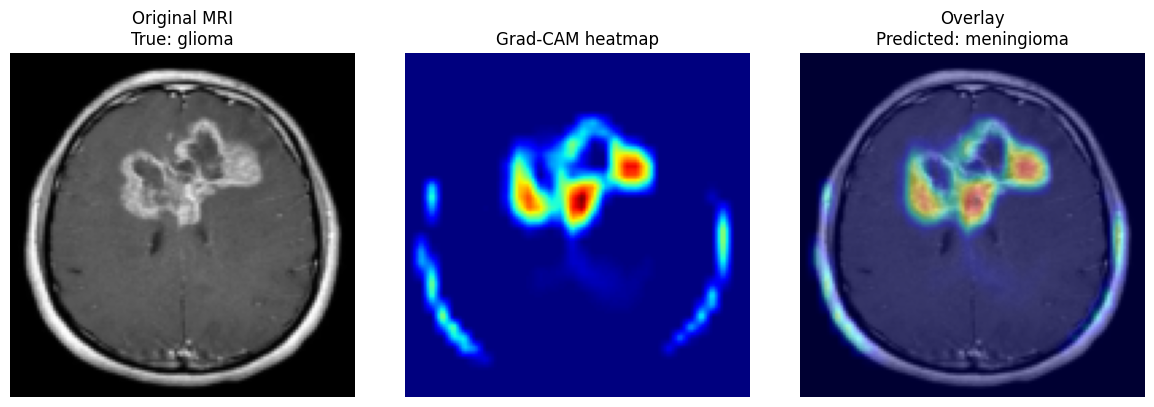

In [9]:
import matplotlib.pyplot as plt
import cv2

grad_cam = GradCAM(model, model.conv3)

sample_image, sample_label = test_data[0]
input_tensor = sample_image.unsqueeze(0).to(device)

output = model(input_tensor)
predicted_class = output.argmax(dim=1).item()

cam = grad_cam.generate(input_tensor, predicted_class)

cam_resized = cv2.resize(cam, (128, 128))

original_img = sample_image.squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(original_img, cmap="gray")
axes[0].set_title(f"Original MRI\nTrue: {class_names[sample_label]}")
axes[0].axis("off")

axes[1].imshow(cam_resized, cmap="jet")
axes[1].set_title("Grad-CAM heatmap")
axes[1].axis("off")

axes[2].imshow(original_img, cmap="gray")
axes[2].imshow(cam_resized, cmap="jet", alpha=0.4)
axes[2].set_title(f"Overlay\nPredicted: {class_names[predicted_class]}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [10]:
import random

glioma_idx = class_names.index("glioma")
meningioma_idx = class_names.index("meningioma")

examples_to_show = []

for i in range(len(test_data)):
    img, label = test_data[i]
    input_tensor = img.unsqueeze(0).to(device)
    output = model(input_tensor)
    pred = output.argmax(dim=1).item()

    if label == glioma_idx and pred == glioma_idx and len(examples_to_show) == 0:
        examples_to_show.append((i, "Correct glioma"))
    elif label == meningioma_idx and pred == meningioma_idx and len(examples_to_show) == 1:
        examples_to_show.append((i, "Correct meningioma"))
    elif label == glioma_idx and pred == meningioma_idx and len(examples_to_show) == 2:
        examples_to_show.append((i, "Glioma misclassified as meningioma"))

    if len(examples_to_show) == 3:
        break

print(examples_to_show)

[(1, 'Correct glioma'), (400, 'Correct meningioma')]


In [11]:
print(len(examples_to_show))


2


In [12]:
glioma_idx = class_names.index("glioma")
meningioma_idx = class_names.index("meningioma")

confusion_cases = []

for i in range(len(test_data)):
    img, label = test_data[i]
    input_tensor = img.unsqueeze(0).to(device)
    output = model(input_tensor)
    pred = output.argmax(dim=1).item()

    if label == glioma_idx and pred == meningioma_idx:
        confusion_cases.append(i)

print(f"Found {len(confusion_cases)} glioma->meningioma confusions")
print(confusion_cases[:5])

Found 27 glioma->meningioma confusions
[0, 8, 11, 30, 38]


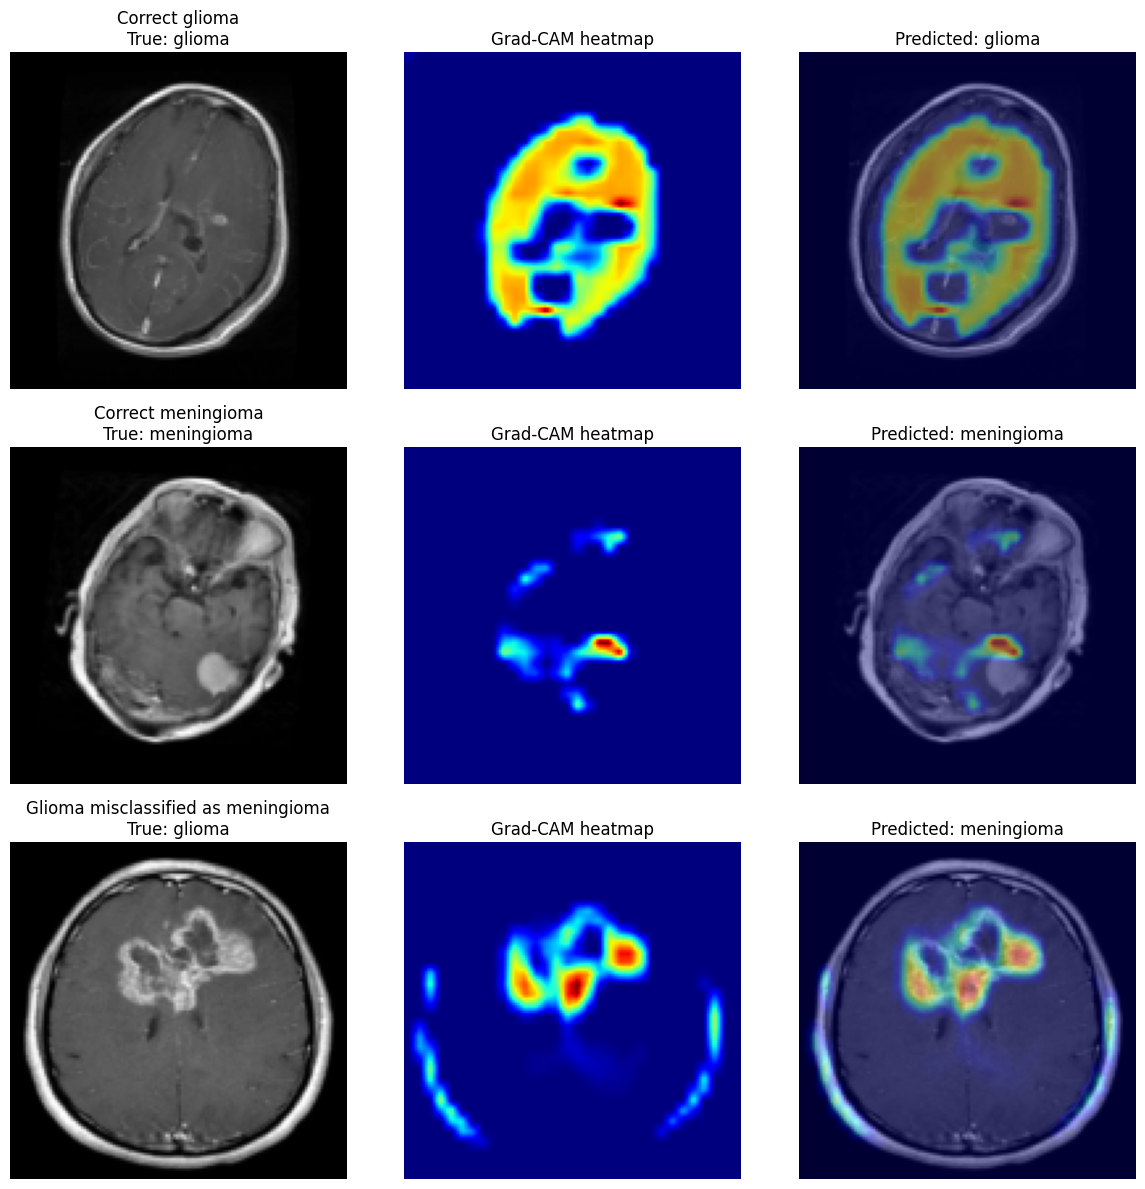

In [13]:
def show_gradcam(idx, title_prefix):
    img, label = test_data[idx]
    input_tensor = img.unsqueeze(0).to(device)

    output = model(input_tensor)
    predicted_class = output.argmax(dim=1).item()

    cam = grad_cam.generate(input_tensor, predicted_class)
    cam_resized = cv2.resize(cam, (128, 128))
    original_img = img.squeeze().numpy()

    return original_img, cam_resized, class_names[label], class_names[predicted_class]

examples = [
    (1, "Correct glioma"),
    (400, "Correct meningioma"),
    (0, "Glioma misclassified as meningioma")
]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row, (idx, description) in enumerate(examples):
    original_img, cam_resized, true_label, pred_label = show_gradcam(idx, description)

    axes[row, 0].imshow(original_img, cmap="gray")
    axes[row, 0].set_title(f"{description}\nTrue: {true_label}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(cam_resized, cmap="jet")
    axes[row, 1].set_title("Grad-CAM heatmap")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(original_img, cmap="gray")
    axes[row, 2].imshow(cam_resized, cmap="jet", alpha=0.4)
    axes[row, 2].set_title(f"Predicted: {pred_label}")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()
